In [90]:
import numpy as np
import pandas as pd

text_emb = np.load("text_embeddings.npy")
ids = np.load("ids.npy")

df_emb = pd.DataFrame({
    "id": ids,
    "text_embedding": list(text_emb)
})

In [91]:
audio_emb = np.load("audio_embeddings.npy")
audio_ids = np.load("audio_ids.npy")

df_audio = pd.DataFrame({
    "id": audio_ids,
    "audio_embedding": list(audio_emb)
})

In [92]:
df_emb = df_emb.merge(df_audio, on="id", how="left")

In [93]:
video_embs = np.load("vision_embeddings.npy")
video_ids = np.load("vision_ids.npy")

df_video = pd.DataFrame({
    "id": video_ids,
    "video_embedding": list(video_embs)
})

In [94]:
df_emb = df_emb.merge(df_video, on="id", how="left")

In [95]:
import numpy as np

def normalize(v):
    norm = np.linalg.norm(v)
    return v if norm == 0 else v / norm

def fuse_equal(row):
    embs = []

    if isinstance(row["video_embedding"], np.ndarray):
        embs.append(normalize(row["video_embedding"]))

    if isinstance(row["audio_embedding"], np.ndarray):
        embs.append(normalize(row["audio_embedding"]))

    if isinstance(row["text_embedding"], np.ndarray):
        embs.append(normalize(row["text_embedding"]))

    if len(embs) == 0:
        return None

    # equal weighting
    fused = np.mean(embs, axis=0)

    # normalize final embedding
    return normalize(fused)

df_emb["fused_embedding"] = df_emb.apply(fuse_equal, axis=1)

In [96]:
import umap

In [97]:
import numpy as np
import hdbscan

# keep only rows that have a fused embedding
df_cluster = df_emb.dropna(subset=["fused_embedding"]).copy().reset_index(drop=True)

# stack into (N, D)
X = np.stack(df_cluster["fused_embedding"].values)

# 2. reduce dimensionality
reducer = umap.UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_reduced = reducer.fit_transform(X)

# 3. cluster
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=26,
    min_samples=6,
    metric="euclidean",
)

labels = clusterer.fit_predict(X_reduced)

# store back in df
df_cluster["cluster"] = labels
df_cluster["cluster_prob"] = clusterer.probabilities_

print("n rows:", len(df_cluster))
print("n clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise points:", int((labels == -1).sum()))

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n rows: 1549
n clusters: 7
noise points: 411


In [5]:
import numpy as np
import umap
import matplotlib.pyplot as plt

X = np.stack(df_cluster["fused_embedding"].values)
labels = df_cluster["cluster"].values

reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_2d = reducer_2d.fit_transform(X)

df_cluster["umap_x"] = X_2d[:, 0]
df_cluster["umap_y"] = X_2d[:, 1]

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

for cluster_id in unique_labels:
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        label_text = f"Noise ({n_points})"
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=12,
            alpha=0.6,
            c="lightgray",
            label=label_text,
        )
    else:
        label_text = f"Cluster {cluster_id} ({n_points})"
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=18,
            alpha=0.85,
            label=label_text,
        )

plt.title("UMAP projection of fused TikTok embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'df_cluster' is not defined

In [44]:
df_cluster.to_pickle("tiktok_id_with_embeddings.pkl")

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

results = []

for cluster_id in sorted(df_cluster["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    cluster_embeddings = np.stack(cluster_df["fused_embedding"].values)

    # pairwise distance matrix
    dist_matrix = cosine_distances(cluster_embeddings)

    # medoid = point with smallest total distance
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # distances to medoid
    medoid_distances = dist_matrix[medoid_idx]

    # get 10 nearest (including medoid itself)
    top_k_idx = np.argsort(medoid_distances)[:20]

    top_k_df = cluster_df.iloc[top_k_idx].copy()
    top_k_df["distance_to_medoid"] = medoid_distances[top_k_idx]
    top_k_df["cluster_id"] = cluster_id

    results.append(top_k_df)

df_medoid_neighbors = pd.concat(results).reset_index(drop=True)

print(df_medoid_neighbors.head())

                    id                                     text_embedding  \
0  7554407144334953742  [0.95751333, 0.0611063, -0.89676195, -2.106427...   
1  7608437702354144543  [0.95751333, 0.0611063, -0.89676195, -2.106427...   
2  7539415943282199839  [0.95751333, 0.0611063, -0.89676195, -2.106427...   
3  7509244206439877910  [0.95751333, 0.0611063, -0.89676195, -2.106427...   
4  7603950650455608598  [0.95751333, 0.0611063, -0.89676195, -2.106427...   

                                     audio_embedding  \
0  [-0.12715974, -0.22697787, -0.051849056, 0.289...   
1  [-0.42646262, -0.2245105, 0.1595947, -0.075277...   
2  [-0.13809863, -0.19239102, -0.2115932, 0.47438...   
3  [-0.18041658, -0.45773602, -0.5228637, -0.2745...   
4  [0.088001125, 0.05027849, 0.24332094, 0.026500...   

                                     video_embedding  \
0  [-0.00070385303, 0.057472203, 0.028581984, -0....   
1  [0.029389193, 0.04332461, 0.0087100305, -0.002...   
2  [-0.026764816, 0.04702069, 0.

In [43]:
df_medoid_neighbors.to_pickle("medoid_neighbors.pkl")

### Scene based concatenated embeddings

In [1]:
import pandas as pd
import numpy as np

In [78]:
df_emb = pd.read_feather("combined_files_with_metadata_with_scene.feather")

In [3]:
import umap

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:10: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.optimize import curve_fit
/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
import numpy as np
import hdbscan

# keep only rows that have a fused embedding
df_cluster = df_emb.dropna(subset=["fused_embedding_concat_by_scene"]).copy().reset_index(drop=True)

# stack into (N, D)
X = np.stack(df_cluster["fused_embedding_concat_by_scene"].values)

# 2. reduce dimensionality
reducer = umap.UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_reduced = reducer.fit_transform(X)

# 3. cluster
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=3,
    metric="euclidean",
)

labels = clusterer.fit_predict(X_reduced)

# store back in df
df_cluster["cluster"] = labels
df_cluster["cluster_prob"] = clusterer.probabilities_

print("n rows:", len(df_cluster))
print("n clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise points:", int((labels == -1).sum()))

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n rows: 1549
n clusters: 4
noise points: 106


/var/folders/vn/pqv9p4rs4wzbkzsr396jhw_00000gn/T/ipykernel_70704/3516735267.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


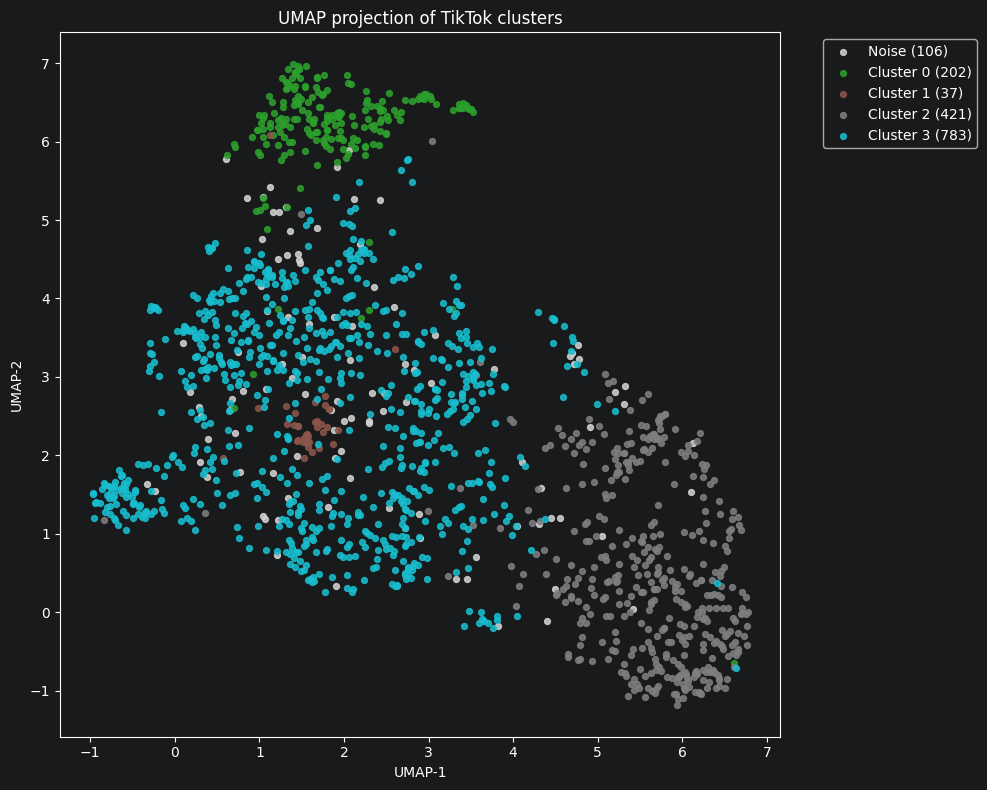

In [37]:
X_2d = df_cluster[["umap_x", "umap_y"]].values
labels = df_cluster["cluster"].values

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

# get a colormap
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, cluster_id in enumerate(unique_labels):
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        color = "lightgray"
        label_name = f"Noise ({n_points})"
    else:
        color = cmap(i)
        label_name = f"Cluster {cluster_id} ({n_points})"

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.85,
        color=color,
        label=label_name,
    )

plt.title("UMAP projection of TikTok clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

results = []

for cluster_id in sorted(df_cluster["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    cluster_embeddings = np.stack(cluster_df["fused_embedding_concat_by_scene"].values)

    # pairwise distance matrix
    dist_matrix = cosine_distances(cluster_embeddings)

    # medoid = point with smallest total distance
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # distances to medoid
    medoid_distances = dist_matrix[medoid_idx]

    # get 10 nearest (including medoid itself)
    top_k_idx = np.argsort(medoid_distances)[:20]

    top_k_df = cluster_df.iloc[top_k_idx].copy()
    top_k_df["distance_to_medoid"] = medoid_distances[top_k_idx]
    top_k_df["cluster_id"] = cluster_id

    results.append(top_k_df)

df_medoid_neighbors = pd.concat(results).reset_index(drop=True)

print(df_medoid_neighbors.head())

                    id            thread_id  \
0  7539415943282199839  7539415943282199839   
1  7611566904112663822  7611566904112663822   
2  7554407144334953742  7554407144334953742   
3  7609797565072084257  7609797565072084257   
4  7525289026916551942  7525289026916551942   

                                             author  \
0  edff719216ceb32df0febc4e0b68a6b861eaf7185d865cf6   
1  8ec7b0077677ead7193f7642e11b0a77ee3dfc592b3a773a   
2  b12a53f6e71703f79a49576f404edfa964489ff5fa4bba27   
3  b7f3258cafb929e8453d9b10f33e4c1a3fc1ba1fff0894c3   
4  b51f871cdd7e73b6bcd9c6f47e3836f5de6d8e8f16ed6876   

                                                body            timestamp  \
0                                                NaN  2025-08-17 05:04:50   
1               #slowestvq #inslowestvqwetrust #fyp   2026-02-27 15:27:53   
2                                                NaN  2025-09-26 14:38:14   
3  🎠 #zweefmolenwiekstra #kermis #reiziger #zweve...  2026-02-22 21:01:19   
4

In [39]:
df_medoid_neighbors.to_feather("medoid_neighbors_by_scene.feather")

In [41]:
import numpy as np
import hdbscan

# keep only rows that have a fused embedding
df_cluster = df_emb.dropna(subset=["fused_embedding_concat_by_scene_v5_t3_a2"]).copy().reset_index(drop=True)

# stack into (N, D)
X = np.stack(df_cluster["fused_embedding_concat_by_scene_v5_t3_a2"].values)

# 2. reduce dimensionality
reducer = umap.UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_reduced = reducer.fit_transform(X)

# 3. cluster
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=27,
    min_samples=10,
    metric="euclidean",
)

labels = clusterer.fit_predict(X_reduced)

# store back in df
df_cluster["cluster"] = labels
df_cluster["cluster_prob"] = clusterer.probabilities_

print("n rows:", len(df_cluster))
print("n clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise points:", int((labels == -1).sum()))

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n rows: 1549
n clusters: 5
noise points: 302


/var/folders/vn/pqv9p4rs4wzbkzsr396jhw_00000gn/T/ipykernel_70704/3516735267.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


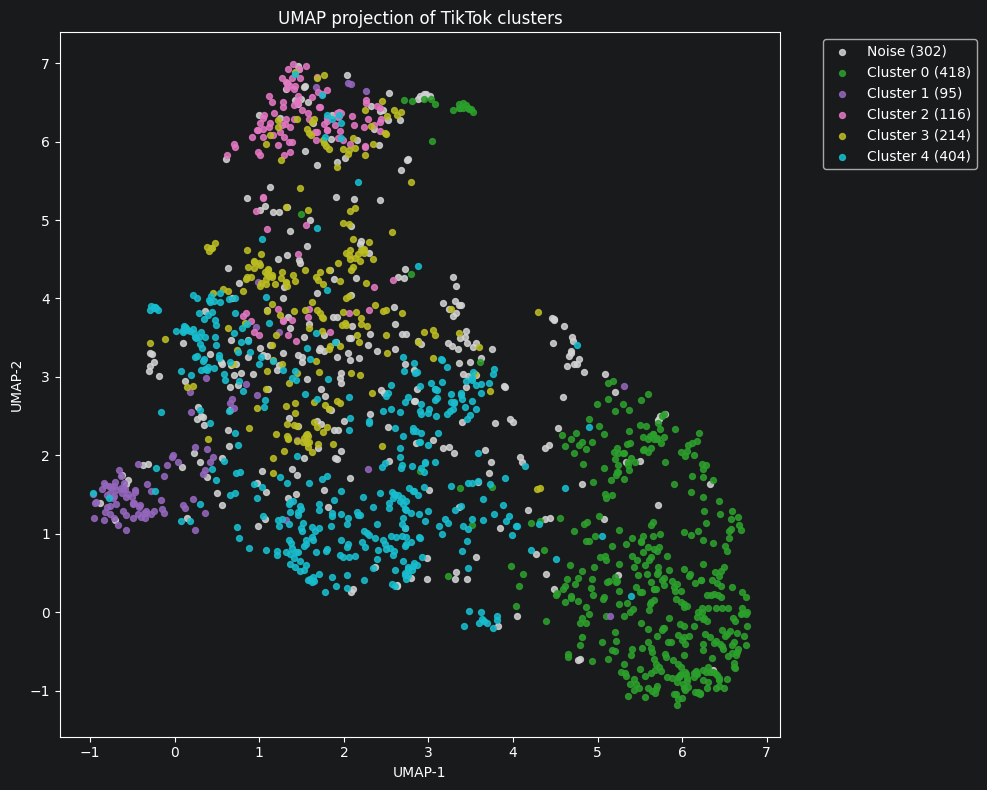

In [42]:
X_2d = df_cluster[["umap_x", "umap_y"]].values
labels = df_cluster["cluster"].values

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

# get a colormap
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, cluster_id in enumerate(unique_labels):
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        color = "lightgray"
        label_name = f"Noise ({n_points})"
    else:
        color = cmap(i)
        label_name = f"Cluster {cluster_id} ({n_points})"

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.85,
        color=color,
        label=label_name,
    )

plt.title("UMAP projection of TikTok clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

results = []

for cluster_id in sorted(df_cluster["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    cluster_embeddings = np.stack(cluster_df["fused_embedding_concat_by_scene_v5_t3_a2"].values)

    # pairwise distance matrix
    dist_matrix = cosine_distances(cluster_embeddings)

    # medoid = point with smallest total distance
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # distances to medoid
    medoid_distances = dist_matrix[medoid_idx]

    # get 10 nearest (including medoid itself)
    top_k_idx = np.argsort(medoid_distances)[:20]

    top_k_df = cluster_df.iloc[top_k_idx].copy()
    top_k_df["distance_to_medoid"] = medoid_distances[top_k_idx]
    top_k_df["cluster_id"] = cluster_id

    results.append(top_k_df)

df_medoid_neighbors = pd.concat(results).reset_index(drop=True)

print(df_medoid_neighbors.head())

                    id            thread_id  \
0  7608652401439984917  7608652401439984917   
1  7611640995993685269  7611640995993685269   
2  7597326917724900616  7597326917724900616   
3  7603413940210535694  7603413940210535694   
4  7615379950832471329  7615379950832471329   

                                             author  \
0  fd522675c4a6c0bd2748f42428c6baf4d636180289cf74d6   
1  fd522675c4a6c0bd2748f42428c6baf4d636180289cf74d6   
2  443884597f095e862a3a6ec23fa5de83c92e79ffbcefb488   
3  86104d5561af6cd0ea7e1c3c42451003c4477863394b4c05   
4  c9d31633b3adf832035158e561c1da3606295f7b89de2c3f   

                                                body            timestamp  \
0  what would my life look like if I wasn’t livin...  2026-02-19 18:57:29   
1  life is about to get a whole lot more interest...  2026-02-27 20:14:43   
2  Replying to @Leahfofeah how i got my landline ...  2026-01-20 06:28:42   
3               this year we’re going analog 🤍🧚🏼‍♂️   2026-02-06 18:00:00   
4

In [44]:
df_medoid_neighbors.to_feather("medoid_neighbors_by_scene_v5_t3_a2.feather")

In [74]:
import numpy as np
import hdbscan

# keep only rows that have a fused embedding
df_cluster = df_emb.dropna(subset=["fused_embedding_concat_by_scene_v4_t2_a4"]).copy().reset_index(drop=True)

# stack into (N, D)
X = np.stack(df_cluster["fused_embedding_concat_by_scene_v4_t2_a4"].values)

# 2. reduce dimensionality
reducer = umap.UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_reduced = reducer.fit_transform(X)

# 3. cluster
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=27,
    min_samples=10,
    metric="euclidean",
)

labels = clusterer.fit_predict(X_reduced)

# store back in df
df_cluster["cluster"] = labels
df_cluster["cluster_prob"] = clusterer.probabilities_

print("n rows:", len(df_cluster))
print("n clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise points:", int((labels == -1).sum()))

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n rows: 1549
n clusters: 12
noise points: 537


/var/folders/vn/pqv9p4rs4wzbkzsr396jhw_00000gn/T/ipykernel_70704/3516735267.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


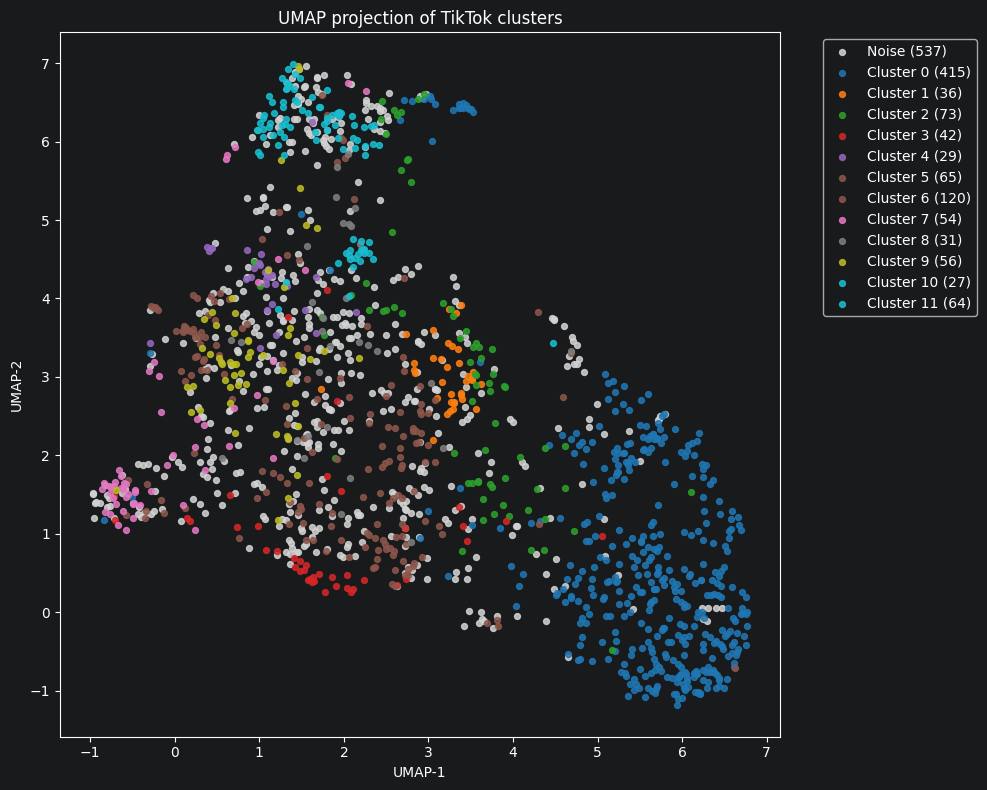

In [75]:
X_2d = df_cluster[["umap_x", "umap_y"]].values
labels = df_cluster["cluster"].values

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

# get a colormap
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, cluster_id in enumerate(unique_labels):
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        color = "lightgray"
        label_name = f"Noise ({n_points})"
    else:
        color = cmap(i)
        label_name = f"Cluster {cluster_id} ({n_points})"

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.85,
        color=color,
        label=label_name,
    )

plt.title("UMAP projection of TikTok clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [76]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

results = []

for cluster_id in sorted(df_cluster["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    cluster_embeddings = np.stack(cluster_df["fused_embedding_concat_by_scene_v4_t2_a4"].values)

    # pairwise distance matrix
    dist_matrix = cosine_distances(cluster_embeddings)

    # medoid = point with smallest total distance
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # distances to medoid
    medoid_distances = dist_matrix[medoid_idx]

    # get 10 nearest (including medoid itself)
    top_k_idx = np.argsort(medoid_distances)[:10]

    top_k_df = cluster_df.iloc[top_k_idx].copy()
    top_k_df["distance_to_medoid"] = medoid_distances[top_k_idx]
    top_k_df["cluster_id"] = cluster_id

    results.append(top_k_df)

df_medoid_neighbors = pd.concat(results).reset_index(drop=True)

print(df_medoid_neighbors.head())

                    id            thread_id  \
0  7608652401439984917  7608652401439984917   
1  7611640995993685269  7611640995993685269   
2  7619317467776568598  7619317467776568598   
3  7603413940210535694  7603413940210535694   
4  7615379950832471329  7615379950832471329   

                                             author  \
0  fd522675c4a6c0bd2748f42428c6baf4d636180289cf74d6   
1  fd522675c4a6c0bd2748f42428c6baf4d636180289cf74d6   
2  468b5a13cf8e90c7a7112a439f5bbe3ba4f1f61c9ea9d1cc   
3  86104d5561af6cd0ea7e1c3c42451003c4477863394b4c05   
4  c9d31633b3adf832035158e561c1da3606295f7b89de2c3f   

                                                body            timestamp  \
0  what would my life look like if I wasn’t livin...  2026-02-19 18:57:29   
1  life is about to get a whole lot more interest...  2026-02-27 20:14:43   
2  how to approach going analog with what we crea...  2026-03-20 12:43:15   
3               this year we’re going analog 🤍🧚🏼‍♂️   2026-02-06 18:00:00   
4

In [77]:
df_medoid_neighbors.to_feather("medoid_neighbors_by_scene_v4_t2_a4.feather")

In [85]:
import numpy as np
import hdbscan

# keep only rows that have a fused embedding
df_cluster = df_emb.dropna(subset=["fused_embedding_concat_by_scene_v3_t2_a5"]).copy().reset_index(drop=True)

# stack into (N, D)
X = np.stack(df_cluster["fused_embedding_concat_by_scene_v3_t2_a5"].values)

# 2. reduce dimensionality
reducer = umap.UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_reduced = reducer.fit_transform(X)

# 3. cluster
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=27,
    min_samples=10,
    metric="euclidean",
)

labels = clusterer.fit_predict(X_reduced)

# store back in df
df_cluster["cluster"] = labels
df_cluster["cluster_prob"] = clusterer.probabilities_

print("n rows:", len(df_cluster))
print("n clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise points:", int((labels == -1).sum()))

/Users/joeechua/Documents/GitHub/ImageBind/imagebind-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n rows: 1549
n clusters: 12
noise points: 540


/var/folders/vn/pqv9p4rs4wzbkzsr396jhw_00000gn/T/ipykernel_70704/3516735267.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


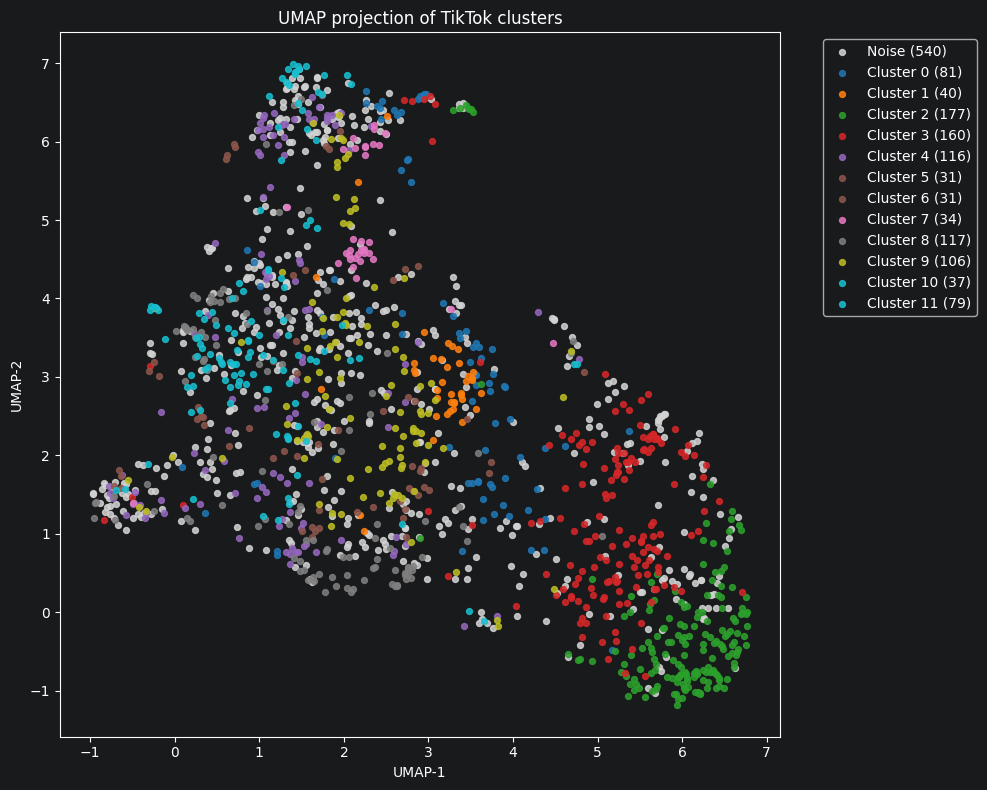

In [86]:
X_2d = df_cluster[["umap_x", "umap_y"]].values
labels = df_cluster["cluster"].values

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

# get a colormap
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, cluster_id in enumerate(unique_labels):
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        color = "lightgray"
        label_name = f"Noise ({n_points})"
    else:
        color = cmap(i)
        label_name = f"Cluster {cluster_id} ({n_points})"

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.85,
        color=color,
        label=label_name,
    )

plt.title("UMAP projection of TikTok clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [81]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

results = []

for cluster_id in sorted(df_cluster["cluster"].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    cluster_embeddings = np.stack(cluster_df["fused_embedding_concat_by_scene_v3_t2_a5"].values)

    # pairwise distance matrix
    dist_matrix = cosine_distances(cluster_embeddings)

    # medoid = point with smallest total distance
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))

    # distances to medoid
    medoid_distances = dist_matrix[medoid_idx]

    # get 10 nearest (including medoid itself)
    top_k_idx = np.argsort(medoid_distances)[:10]

    top_k_df = cluster_df.iloc[top_k_idx].copy()
    top_k_df["distance_to_medoid"] = medoid_distances[top_k_idx]
    top_k_df["cluster_id"] = cluster_id

    results.append(top_k_df)

df_medoid_neighbors = pd.concat(results).reset_index(drop=True)

print(df_medoid_neighbors.head())

                    id            thread_id  \
0  7501269975080996117  7501269975080996117   
1  7603244376390782229  7603244376390782229   
2  7610508023890513170  7610508023890513170   
3  7607794730990112022  7607794730990112022   
4  7622802807703309590  7622802807703309590   

                                             author  \
0  33d7db74215ad763b22dd1be40c61c63f2756da8da38ef99   
1  579644df8a956a3a597c59d828bf720551f4ac53873fe5b1   
2  6e5e2ca795dd566609020d86655f67b1821dfc5fb6e5ad47   
3  d6ea98e5ebb24ad63ef440096e4840418e3f5f56dca91623   
4  374a82cf72962f372ffa63dd0b8d15841332db8710385297   

                                                body            timestamp  \
0  feels like HOME🇯🇵 #japan #8mm #film #tokyo #an...  2025-05-06 09:58:48   
1  Digital detox #Brainrot #brainrotawareness #br...  2026-02-05 05:11:34   
2  life when I’m offline > #selfimprovement #fitn...  2026-02-24 18:58:13   
3  anything peaceful  #slowlife #slowliving #quie...  2026-02-17 11:29:12   
4

In [82]:
df_medoid_neighbors.to_feather("medoid_neighbors_by_scene_v3_t2_a5.feather")

In [87]:
df_cluster["cluster"].values

array([-1,  8,  3, ...,  3,  3, 11])

In [89]:
df_cluster["cluster"].value_counts().sort_index()

cluster
-1     540
 0      81
 1      40
 2     177
 3     160
 4     116
 5      31
 6      31
 7      34
 8     117
 9     106
 10     37
 11     79
Name: count, dtype: int64